# André

In [4]:
import pandas as pd

# Data

In [9]:
data = pd.read_csv('../data/horoscope_saved.csv')
data.columns

# this dataset is not real is generated for demonstration purposes only

Index(['sign', 'category', 'date', 'horoscope'], dtype='object')

In [12]:
data.head()

,sign,category,date,horoscope
0,aries,general,20200617,"There's a great day ahead of you, Aries. You'l..."
1,aries,general,20200618,People will understand and appreciate your des...
2,aries,general,20200619,You are very interested in technological break...
3,aries,general,20200620,Stress from overwork could have you feeling we...
4,aries,general,20200621,This is a good day to stand up for yourself an...


not all of them start with @

In [96]:
no_at_tweets = social_media_engagement[~social_media_engagement['tweet'].str.strip().str.startswith('@')]

# Display these tweets
print(no_at_tweets[['tweet']])

                                                  tweet
6      Oh no - it's all gone to shit  http://is.gd/rc0L
7     my boyfriend is going out of town for 2 days a...
8                            crashing.  night everyone!
28    I should actually go to sleep. I need to get u...
48                   omg why dose it always rain on F1 
...                                                 ...
5343  if your bored and want a wee giggle http://tin...
5346  in BETTER news...MARILYN MANSON IS PLAYING FES...
5347  Thanks to @SNIZWHIZ @Flying_Roundhouse @J2ad @...
5349  Thanks to @storylet @ShinylVinyl @shanti45 for...
5353  Thanks to @LikeAnAngel @tubilino @postpunk for...

[1351 rows x 1 columns]


# Code

In [98]:
# Tokenize text_content into a list of words
import re

def tokenize(text):
    # return a list of lowercased word strings including @mentions; handles NaN
    if pd.isna(text):
        return []
    # "@\w+" matches @mentions, "\w+" matches other words
    return re.findall(r"@\w+|\w+", str(text).lower())

# Apply tokenizer to the 'text_content' column; adjust column name if different
social_media_engagement['tokens'] = social_media_engagement['tweet'].apply(tokenize)
social_media_engagement['mentions'] = social_media_engagement['tokens'].apply(
    lambda x: [word for word in x if word.startswith('@')] if x else [])

# Show original text and tokens (first few rows)
social_media_engagement[['tweet','tokens', "mentions"]].head(20)

,tweet,tokens,mentions
0,@MissxMarisa haven't heard from Hannah at all ...,"[@missxmarisa, haven, t, heard, from, hannah, ...",[@missxmarisa]
1,@OscarTG Morning. No sun here unfortunately,"[@oscartg, morning, no, sun, here, unfortunately]",[@oscartg]
2,@jason_2008 Hello! Im out of coffee this morni...,"[@jason_2008, hello, im, out, of, coffee, this...",[@jason_2008]
3,@KingKiwi i want to be somewhere with no rain...,"[@kingkiwi, i, want, to, be, somewhere, with, ...",[@kingkiwi]
4,@Seamonkey86 I am on a healthy eating kick! I ...,"[@seamonkey86, i, am, on, a, healthy, eating, ...",[@seamonkey86]
5,@Zanna85 i don't like that day,"[@zanna85, i, don, t, like, that, day]",[@zanna85]
6,Oh no - it's all gone to shit http://is.gd/rc0L,"[oh, no, it, s, all, gone, to, shit, http, is,...",[]
7,my boyfriend is going out of town for 2 days a...,"[my, boyfriend, is, going, out, of, town, for,...",[]
8,crashing. night everyone!,"[crashing, night, everyone]",[]
9,@tweetchild Clean Me!,"[@tweetchild, clean, me]",[@tweetchild]


In [99]:
social_media_engagement["token_size"] = social_media_engagement["tokens"].apply(len)

stats about size of tweets

In [100]:
social_media_engagement["token_size"].describe()

count    5356.000000
mean       12.145818
std         6.916564
min         1.000000
25%         7.000000
50%        11.000000
75%        17.000000
max        33.000000
Name: token_size, dtype: float64

pivot_longer basically

In [101]:
# Explode tokens into individual word rows for analysis
# This will create a DataFrame with one word per row (column name: 'word')
exploded_words = social_media_engagement[['tokens']].explode('tokens').reset_index()
exploded_words = exploded_words.rename(columns={'tokens':'word'})

# Show sample
exploded_words

# Optionally save to CSV for downstream tasks (uncomment to enable)
# exploded_words.to_csv('../data/text_words_exploded.csv', index=False)

,index,word
0,0,@missxmarisa
1,0,haven
2,0,t
3,0,heard
4,0,from
...,...,...
65048,5355,do
65049,5355,not
65050,5355,play
65051,5355,fair


Word counter!

               word  count
0                 i   2794
1               you   1500
2                 a   1398
3                me   1237
4                to   1224
...             ...    ...
7481         equals      1
7482     backfiring      1
7483  @jesswholohan      1
7484     @agerstein      1
7485          8bl78      1

[7486 rows x 2 columns]


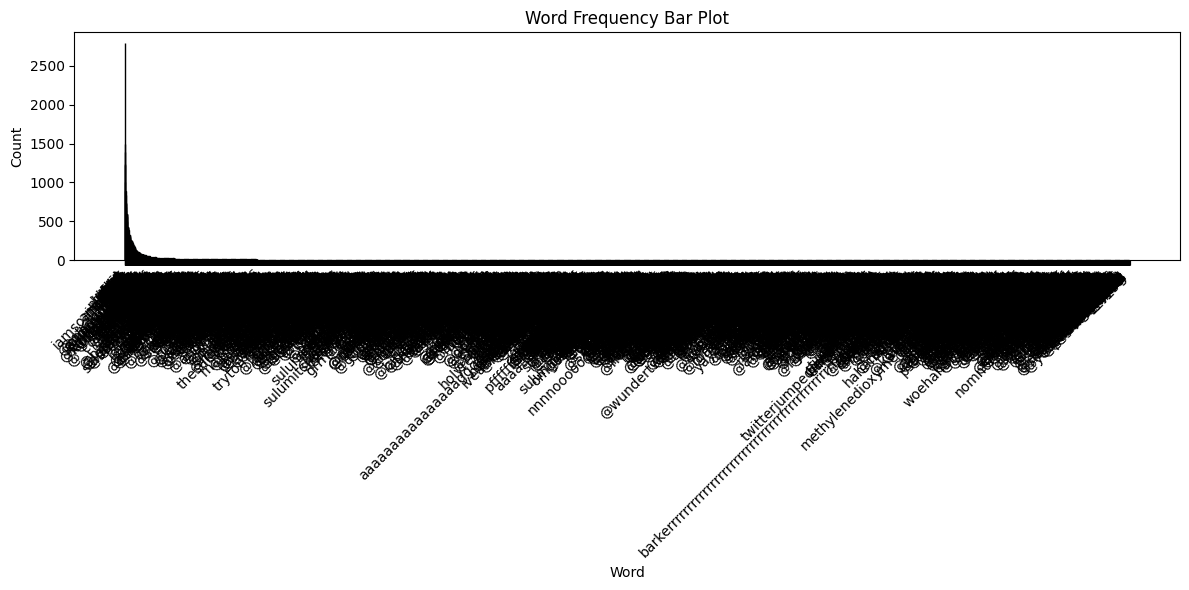

In [102]:
word_counter = exploded_words['word'].value_counts().reset_index()
word_counter.columns = ['word', 'count']

# Show the counts
print(word_counter)

import matplotlib.pyplot as plt

# Sort word_counter by count descending (already done by value_counts)
word_counter_sorted = word_counter.sort_values(by='count', ascending=False)

# Plot bar plot: each bar for one word, ordered by frequency
plt.figure(figsize=(12, 6))
plt.bar(word_counter_sorted['word'], word_counter_sorted['count'], color='skyblue', edgecolor='black')

plt.title('Word Frequency Bar Plot')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability

plt.tight_layout()
plt.show()


In [103]:
word_counter.head(20)

,word,count
0,i,2794
1,you,1500
2,a,1398
3,me,1237
4,to,1224
5,it,1004
6,good,884
7,the,844
8,help,735
9,am,734


In [104]:
# Find frequent itemsets (count-based, no external libraries)
# Configurable parameters
min_support = 0.02   # minimum support (fraction of transactions)
max_k = 3           # maximum size of itemsets to search (1..max_k)

from collections import Counter
from itertools import combinations

# Prepare transactions: list of token lists (unique items per transaction)
transactions = [list(dict.fromkeys(t)) for t in social_media_engagement['tokens'].tolist()]
num_tx = len(transactions)

print(f"Number of transactions: {num_tx}")

def get_frequent_itemsets(transactions, max_k=2, min_support=0.05):
    n = len(transactions)
    results = []  # list of dicts: {'itemset': tuple, 'count': int, 'support': float}

    # Count single items
    single_counts = Counter()
    for t in transactions:
        single_counts.update(set(t))

    # collect frequent 1-itemsets
    prev_freq = {}
    for item, cnt in single_counts.items():
        support = cnt / n
        if support >= min_support:
            results.append({'itemset': (item,), 'count': cnt, 'support': support})
            prev_freq[(item,)] = cnt

    # iterate for k = 2..max_k
    k = 2
    while k <= max_k and prev_freq:
        candidate_counts = Counter()
        for t in transactions:
            items = sorted(set(t))
            if len(items) < k:
                continue
            for comb in combinations(items, k):
                candidate_counts[comb] += 1

        # filter by min_support
        freq_k = {}
        for comb, cnt in candidate_counts.items():
            support = cnt / n
            if support >= min_support:
                results.append({'itemset': comb, 'count': cnt, 'support': support})
                freq_k[comb] = cnt

        prev_freq = freq_k
        k += 1

    # return results as DataFrame sorted by k and support desc
    if not results:
        return pd.DataFrame(columns=['itemset','count','support','k'])

    df = pd.DataFrame(results)
    df['k'] = df['itemset'].apply(len)
    df = df.sort_values(['k','support'], ascending=[True, False]).reset_index(drop=True)
    return df

# Run the mining
freq_itemsets_df = get_frequent_itemsets(transactions, max_k=max_k, min_support=min_support)

if freq_itemsets_df.empty:
    print("No frequent itemsets found with the current min_support and max_k.")
else:
    display(freq_itemsets_df)

# Optional: save to CSV
# freq_itemsets_df.to_csv('../data/frequent_itemsets.csv', index=False)

# Quick summary: top itemsets by support
print('\nTop itemsets by support:')
print(freq_itemsets_df.head(20))

Number of transactions: 5356


,itemset,count,support,k
0,"(i,)",2138,0.399178,1
1,"(you,)",1298,0.242345,1
2,"(a,)",1283,0.239544,1
3,"(me,)",1214,0.226662,1
4,"(to,)",1078,0.201270,1
...,...,...,...,...
2113,"(ch, will, your)",143,0.026699,3
2114,"(1, com, drop)",139,0.025952,3
2115,"(i, it, to)",122,0.022778,3
2116,"(i, the, to)",114,0.021285,3



Top itemsets by support:
      itemset  count   support  k
0        (i,)   2138  0.399178  1
1      (you,)   1298  0.242345  1
2        (a,)   1283  0.239544  1
3       (me,)   1214  0.226662  1
4       (to,)   1078  0.201270  1
5     (good,)    874  0.163181  1
6       (it,)    865  0.161501  1
7     (help,)    735  0.137229  1
8      (the,)    725  0.135362  1
9       (am,)    723  0.134989  1
10      (is,)    676  0.126214  1
11     (lol,)    608  0.113518  1
12     (and,)    601  0.112211  1
13  (please,)    592  0.110530  1
14    (home,)    592  0.110530  1
15     (com,)    590  0.110157  1
16    (lost,)    563  0.105116  1
17    (find,)    558  0.104182  1
18     (all,)    478  0.089246  1
19    (that,)    477  0.089059  1


In [109]:
# Show only 1-itemsets (k == 1). Use a safe check in case the 'k' column is missing.
if 'k' in freq_itemsets_df.columns:
    display(freq_itemsets_df[freq_itemsets_df['k'] != 1])
else:
    print("DataFrame has no 'k' column. Available columns:", freq_itemsets_df.columns.tolist())

,itemset,count,support,k
93,"(a, i)",913,0.170463,2
94,"(i, me)",729,0.136109,2
95,"(am, i)",707,0.132001,2
96,"(good, i)",653,0.121919,2
97,"(a, good)",638,0.119119,2
...,...,...,...,...
2113,"(ch, will, your)",143,0.026699,3
2114,"(1, com, drop)",139,0.025952,3
2115,"(i, it, to)",122,0.022778,3
2116,"(i, the, to)",114,0.021285,3


In [106]:
# Exclude certain words from the itemset table (simple and editable)
# Edit this set to exclude words from the results (lowercase)

"""excluded_words = set(['the', 'and', 'is', 'in', 'to', 'of', 
                      'a', 'for', 'on', 'with', 'that', 'it', 
                      'as', 'this', 'at', "s", "your", "my"])"""
excluded_words = set()

# helper: return True if any word in itemset is in excluded_words
def itemset_has_excluded(itemset, excluded):
    return any(word in excluded for word in itemset)

if 'itemset' in globals() or 'freq_itemsets_df' in globals():
    if 'freq_itemsets_df' in globals() and 'itemset' in freq_itemsets_df.columns:
        filtered_itemsets = freq_itemsets_df[~freq_itemsets_df['itemset'].apply(lambda it: itemset_has_excluded(it, excluded_words))]
        print(f"Excluded words: {sorted(list(excluded_words))}")
        print(f"Original itemsets: {len(freq_itemsets_df)}  →  After exclusion: {len(filtered_itemsets)}")
        display(filtered_itemsets)

    else:
        print("`freq_itemsets_df` not available or has no 'itemset' column. Run the mining cell first.")
else:
    print("Frequent itemset DataFrame not found in the notebook namespace.")


Excluded words: []
Original itemsets: 2118  →  After exclusion: 2118


,itemset,count,support,k
0,"(i,)",2138,0.399178,1
1,"(you,)",1298,0.242345,1
2,"(a,)",1283,0.239544,1
3,"(me,)",1214,0.226662,1
4,"(to,)",1078,0.201270,1
...,...,...,...,...
2113,"(ch, will, your)",143,0.026699,3
2114,"(1, com, drop)",139,0.025952,3
2115,"(i, it, to)",122,0.022778,3
2116,"(i, the, to)",114,0.021285,3


In [108]:
# Show only 1-itemsets (k == 1) — placed after the latest code blocks
# This safely checks for the 'k' column and displays only 1-itemsets.
if 'filtered_itemsets' in globals():
    if 'k' in filtered_itemsets.columns:
        display(filtered_itemsets[filtered_itemsets['k'] == 2])
    else:
        print("DataFrame has no 'k' column. Available columns:", filtered_itemsets.columns.tolist())
else:
    print("`freq_itemsets_df` not found. Run the frequent-itemset mining cell first.")

,itemset,count,support,k
93,"(a, i)",913,0.170463,2
94,"(i, me)",729,0.136109,2
95,"(am, i)",707,0.132001,2
96,"(good, i)",653,0.121919,2
97,"(a, good)",638,0.119119,2
...,...,...,...,...
442,"(t, you)",115,0.021471,2
443,"(is, that)",112,0.020911,2
444,"(all, i)",110,0.020538,2
445,"(a, for)",108,0.020164,2
